## 1. Imports

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load Data

In [2]:
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)

payment_file_path = os.path.join(project_root, 'Data', 'raw', 'Olist_ecom_data', 'olist_order_payments_dataset.csv')
payment = pd.read_csv(payment_file_path)


## 3. Initial Data Check

In [6]:
payment.info()


<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [7]:
payment.head(10)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


In [8]:
print('Missing Values:')
print(payment.isnull().sum())
print('\nBasic Stats:')
payment.describe()


Missing Values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Basic Stats:


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


## 4. Data Quality Checks

In [11]:
# Orders with 0 payment value
zero_payment_orders = payment[payment['payment_value'] == 0]
print(f'Orders with 0 payment value: {zero_payment_orders.shape[0]}')
print(zero_payment_orders['payment_type'].value_counts())


Orders with 0 payment value: 9
payment_type
voucher        6
not_defined    3
Name: count, dtype: int64


In [24]:
# Orders with multiple payments (duplicate order_ids)
num_duplicate_order_ids = payment[payment.duplicated('order_id',keep=False)]
print(f'Unique order IDs with multiple payments: {num_duplicate_order_ids["order_id"].nunique()}')


Unique order IDs with multiple payments: 2961


In [25]:
# All payment types before cleaning
print(f'Payment types before cleaning:')
print(payment['payment_type'].value_counts())


Payment types before cleaning:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


## 5. Data Cleaning
> **Note:** Cleaning is done BEFORE KPI calculations to ensure accurate results.

In [12]:
# Drop undefined + 0 value rows (genuine data errors)
payment = payment[~(
    (payment['payment_type'] == 'not_defined') &
    (payment['payment_value'] == 0)
)]

print(f'Rows after cleaning: {len(payment)}')
print(f'Payment types after cleaning:')
print(payment['payment_type'].value_counts())


Rows after cleaning: 103883
Payment types after cleaning:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
Name: count, dtype: int64


## 6. Revenue KPIs — Transaction Level

In [13]:
total_revenue = payment['payment_value'].sum()
aov_transaction = payment['payment_value'].mean()
median_transaction = payment['payment_value'].median()
max_transaction = payment['payment_value'].max()
min_transaction = payment['payment_value'][payment['payment_value'] > 0].min()

print(f'Total Revenue:             R$ {total_revenue:,.2f}')
print(f'Avg Transaction Value:     R$ {aov_transaction:.2f}')
print(f'Median Transaction Value:  R$ {median_transaction:.2f}')
print(f'Max Transaction Value:     R$ {max_transaction:.2f}')
print(f'Min Transaction Value:     R$ {min_transaction:.2f}')


Total Revenue:             R$ 16,008,872.12
Avg Transaction Value:     R$ 154.10
Median Transaction Value:  R$ 100.00
Max Transaction Value:     R$ 13664.08
Min Transaction Value:     R$ 0.01


## 7. Revenue KPIs — Order Level
> **Note:** More accurate AOV — accounts for multi-payment orders by grouping by order_id first.

In [ ]:
order_level = payment.groupby('order_id').agg(
    total_value=('payment_value', 'sum'),
    num_payments=('payment_type', 'count'),
    payment_types=('payment_type', lambda x: ','.join(x.unique()))
).reset_index()
print(order_level.info())
aov_order = order_level['total_value'].mean()
median_order = order_level['total_value'].median()

print(f'True AOV (per order):      R$ {aov_order:.2f}')
print(f'Median Order Value:        R$ {median_order:.2f}')
print(f'Total Unique Orders:       {order_level["order_id"].nunique()}')


                           order_id  total_value  num_payments payment_types
0  00010242fe8c5a6d1ba2dd792cb16214        72.19             1   credit_card
1  00018f77f2f0320c557190d7a144bdd3       259.83             1   credit_card
2  000229ec398224ef6ca0657da4fc703e       216.87             1   credit_card
3  00024acbcdf0a6daa1e931b038114c75        25.78             1   credit_card
4  00042b26cf59d7ce69dfabb4e55b4fd9       218.04             1   credit_card
True AOV (per order):      R$ 160.99
Median Order Value:        R$ 105.29
Total Unique Orders:       99440


## 8. Payment Method Analysis

In [15]:
# Count and % by payment type
payment_count = payment['payment_type'].value_counts().reset_index()
payment_count.columns = ['payment_type', 'count']
payment_count['percentage'] = (payment_count['count'] / len(payment) * 100).round(2)
print(payment_count)


  payment_type  count  percentage
0  credit_card  76795       73.92
1       boleto  19784       19.04
2      voucher   5775        5.56
3   debit_card   1529        1.47


In [16]:
# Revenue by payment type
revenue_by_type = payment.groupby('payment_type')['payment_value'].sum().reset_index()
revenue_by_type.columns = ['payment_type', 'total_revenue']
revenue_by_type['revenue_pct'] = (revenue_by_type['total_revenue'] / total_revenue * 100).round(2)
revenue_by_type = revenue_by_type.sort_values('total_revenue', ascending=False)
print(revenue_by_type)


  payment_type  total_revenue  revenue_pct
1  credit_card    12542084.19        78.34
0       boleto     2869361.27        17.92
3      voucher      379436.87         2.37
2   debit_card      217989.79         1.36


In [17]:
# Average order value by payment type
avg_by_type = payment.groupby('payment_type')['payment_value'].mean().reset_index()
avg_by_type.columns = ['payment_type', 'avg_value']
avg_by_type = avg_by_type.sort_values('avg_value', ascending=False)
print(avg_by_type)


  payment_type   avg_value
1  credit_card  163.319021
0       boleto  145.034435
2   debit_card  142.570170
3      voucher   65.703354


In [18]:
# High value orders (>1000) by payment type
high_value_orders = payment[payment['payment_value'] > 1000]
total_high_value = high_value_orders.shape[0]
high_value_by_type = high_value_orders['payment_type'].value_counts().reset_index()
high_value_by_type.columns = ['payment_type', 'count']
high_value_by_type['pct_of_high_value'] = (high_value_by_type['count'] / total_high_value * 100).round(2)
print(f'High value orders (>R$1000): {total_high_value} ({total_high_value/len(payment)*100:.2f}% of all orders)')
print(high_value_by_type)


High value orders (>R$1000): 1150 (1.11% of all orders)
  payment_type  count  pct_of_high_value
0  credit_card    944              82.09
1       boleto    178              15.48
2   debit_card     15               1.30
3      voucher     13               1.13


### Payment Method Visualizations

C:\Users\phone\AppData\Local\Temp\ipykernel_12852\1012791968.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_count, x='count', y='payment_type', palette='magma', ax=axes[0])
C:\Users\phone\AppData\Local\Temp\ipykernel_12852\1012791968.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_type, x='total_revenue', y='payment_type', palette='rocket', ax=axes[1])


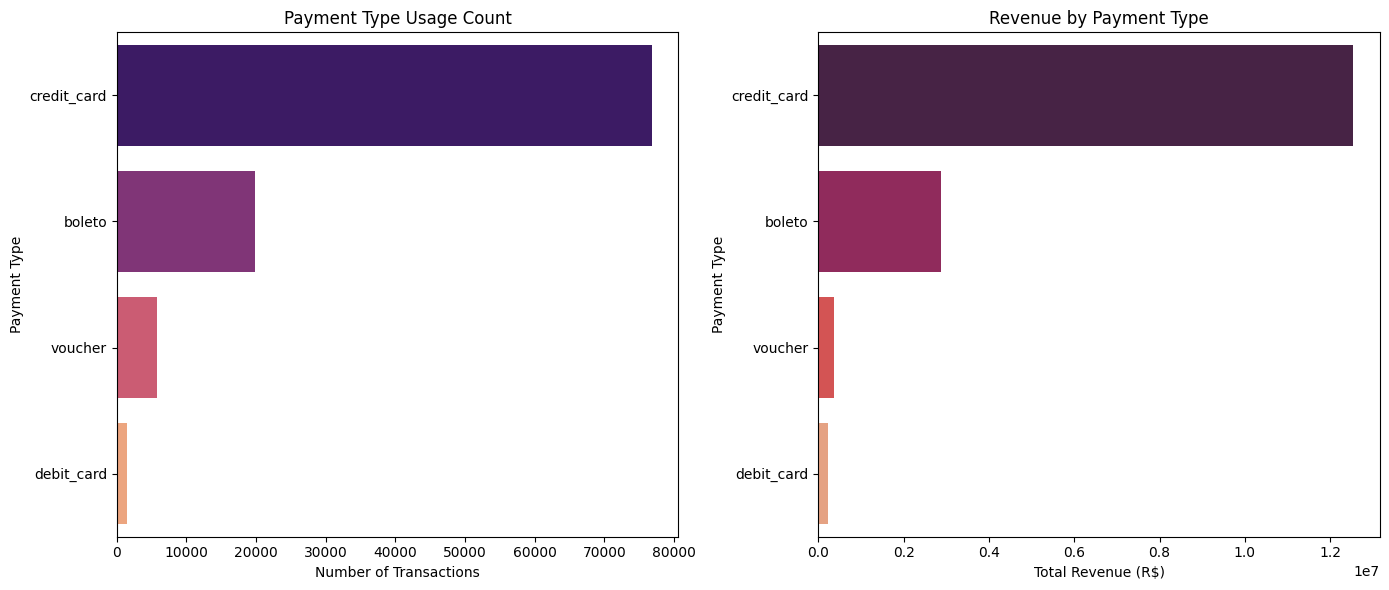

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=payment_count, x='count', y='payment_type', palette='magma', ax=axes[0])
axes[0].set_title('Payment Type Usage Count')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Payment Type')

sns.barplot(data=revenue_by_type, x='total_revenue', y='payment_type', palette='rocket', ax=axes[1])
axes[1].set_title('Revenue by Payment Type')
axes[1].set_xlabel('Total Revenue (R$)')
axes[1].set_ylabel('Payment Type')

plt.tight_layout()
plt.show()


## 9. Installment Analysis

In [20]:
installment_payments = payment[payment['payment_installments'] > 1]
num_installment = installment_payments.shape[0]
installment_rate = (num_installment / len(payment)) * 100

print(f'Orders with installments:           {num_installment}')
print(f'Installment Rate:                   {installment_rate:.2f}%')
print(f'Single Payment Rate:                {100 - installment_rate:.2f}%')

avg_installments = payment['payment_installments'].mean()
print(f'Avg Number of Installments:         {avg_installments:.2f}')

cc_payments = payment[payment['payment_type'] == 'credit_card']
avg_cc_installments = cc_payments['payment_installments'].mean()
print(f'Avg Installments (Credit Card only):{avg_cc_installments:.2f}')

correlation = payment['payment_installments'].corr(payment['payment_value'])
print(f'Correlation installments vs value:  {correlation:.2f}')


Orders with installments:           51338
Installment Rate:                   49.42%
Single Payment Rate:                50.58%
Avg Number of Installments:         2.85
Avg Installments (Credit Card only):3.51
Correlation installments vs value:  0.33


In [21]:
print('Installment distribution (top 15):')
print(payment['payment_installments'].value_counts().sort_index().head(15))


Installment distribution (top 15):
payment_installments
0         2
1     52543
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
Name: count, dtype: int64


### Installment Visualizations

C:\Users\phone\AppData\Local\Temp\ipykernel_12852\1667034032.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=installment_dist, x='installments', y='count', palette='viridis', ax=axes[0])


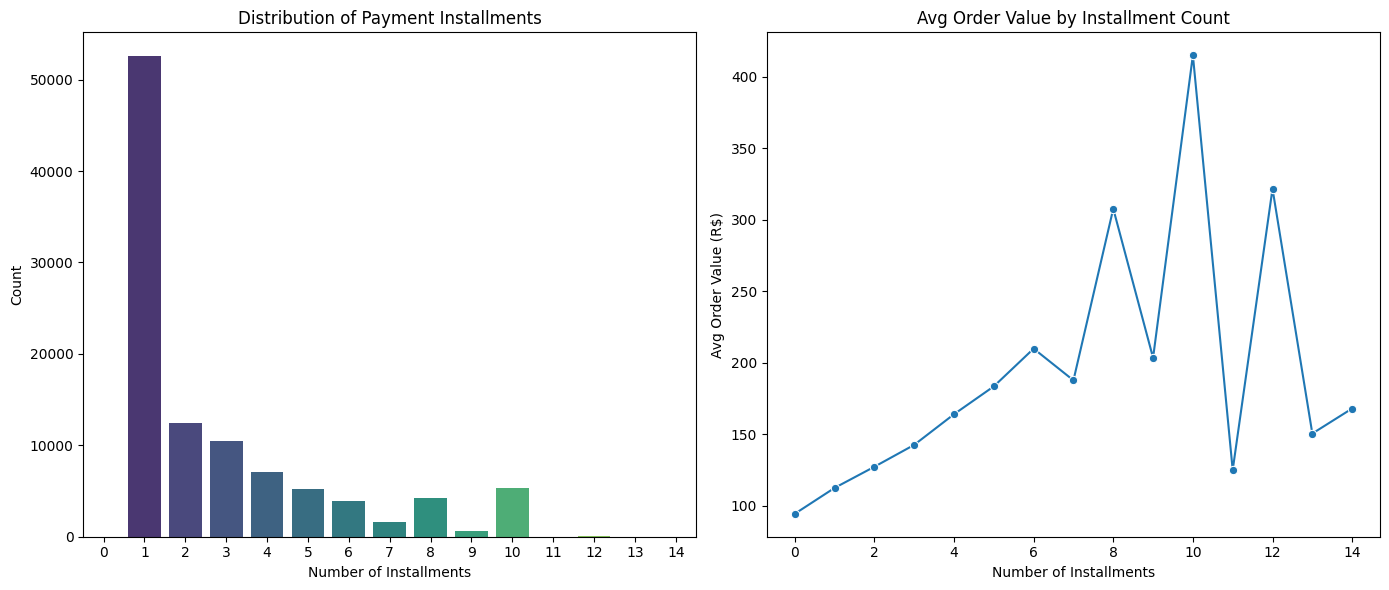

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

installment_dist = payment['payment_installments'].value_counts().sort_index().head(15).reset_index()
installment_dist.columns = ['installments', 'count']
sns.barplot(data=installment_dist, x='installments', y='count', palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Payment Installments')
axes[0].set_xlabel('Number of Installments')
axes[0].set_ylabel('Count')

avg_value_by_installment = payment.groupby('payment_installments')['payment_value'].mean().reset_index().head(15)
sns.lineplot(data=avg_value_by_installment, x='payment_installments', y='payment_value', marker='o', ax=axes[1])
axes[1].set_title('Avg Order Value by Installment Count')
axes[1].set_xlabel('Number of Installments')
axes[1].set_ylabel('Avg Order Value (R$)')

plt.tight_layout()
plt.show()


## 10. Order Value Distribution

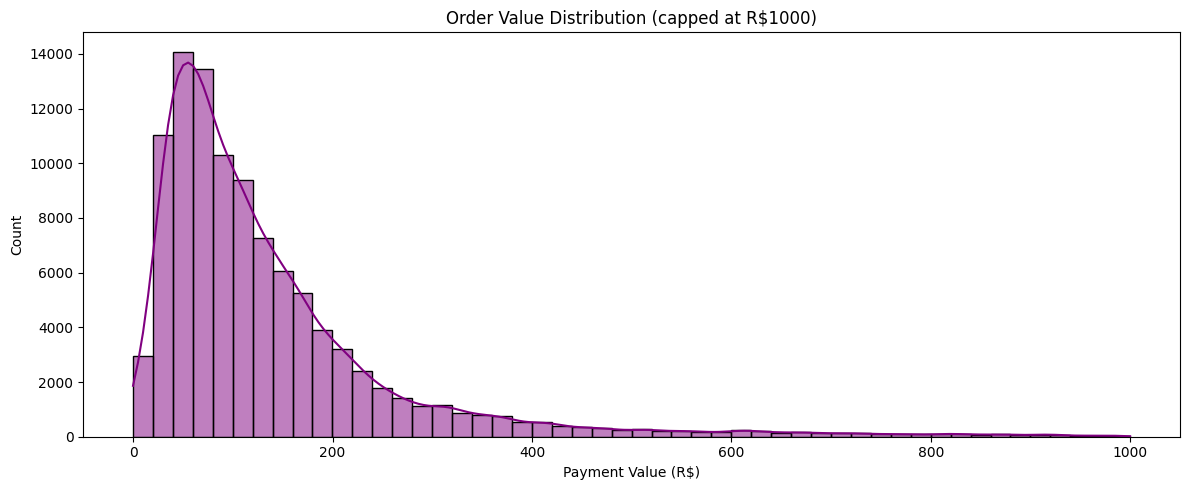

In [23]:
plt.figure(figsize=(12, 5))
sns.histplot(payment[payment['payment_value'] <= 1000]['payment_value'], bins=50, kde=True, color='purple')
plt.title('Order Value Distribution (capped at R$1000)')
plt.xlabel('Payment Value (R$)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## 11. Export for Power BI

In [24]:
output_path = os.path.join(project_root, 'Data', 'processed')
os.makedirs(output_path, exist_ok=True)

# Row level — for payment type analysis in Power BI
payment.to_csv(os.path.join(output_path, 'payments_cleaned.csv'), index=False)

# Order level — for RFM monetary value
order_level.to_csv(os.path.join(output_path, 'payments_order_level.csv'), index=False)

print('✅ Exported payments_cleaned.csv to Data/processed/')
print('✅ Exported payments_order_level.csv to Data/processed/')


✅ Exported payments_cleaned.csv to Data/processed/
✅ Exported payments_order_level.csv to Data/processed/
